### Current approach

I separate the data into in train and test before the PCA.

In [1075]:
import os
import pickle
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, roc_auc_score
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GroupKFold, GroupShuffleSplit
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE
from hmmlearn import hmm
from hmmlearn.hmm import GaussianHMM
import plotly.express as px




In [ ]:
data_path = '/home/edumaba/Public/MPhil_Thesis/Code/uropatch-data-analysis/features_data_main/three_class_raw_2s_yo_0.8.csv'
features = pd.read_csv(data_path)
features.drop(['center_time', 'start_time', 'end_time'], axis= 1, inplace=True)
features


,acc_x_permutation_entropy,acc_x_spectral_entropy,acc_x_mean,acc_x_std,acc_x_range,acc_x_rms,acc_x_var,acc_x_min,acc_x_max,acc_x_time_energy,...,gyr_mag_std,gyr_mag_range,gyr_mag_rms,gyr_mag_var,gyr_mag_min,gyr_mag_max,gyr_mag_time_energy,gyr_mag_spectral_energy,label,experiment_id
0,0.837517,0.656083,1.027208,1.005637,5.349532,1.437520,1.011306,-1.100002,4.249530,243.842623,...,1.742222,7.487364,3.090512,3.035336,0.262540,7.749904,1127.049263,132991.813018,non-void,1
1,0.856472,0.634105,1.049054,0.936724,5.349532,1.406402,0.877451,-1.100002,4.249530,233.399948,...,1.787973,7.614706,2.800308,3.196848,0.135198,7.749904,925.323664,109188.192384,non-void,1
2,0.866184,0.638264,0.996176,0.888607,5.349532,1.334912,0.789622,-1.100002,4.249530,210.274765,...,1.741895,7.657108,2.450640,3.034198,0.092797,7.749904,708.665105,83622.482415,non-void,1
3,0.878813,0.663285,0.929198,0.584101,3.553001,1.097535,0.341174,-0.289933,3.263068,142.140853,...,1.502970,7.657108,1.939446,2.258920,0.092797,7.749904,443.851412,52374.466635,non-void,1
4,0.905723,0.782317,0.762776,0.265824,1.479456,0.807768,0.070662,-0.132898,1.346558,76.993792,...,0.436316,3.250805,0.733959,0.190372,0.076565,3.327370,63.566144,7500.804959,non-void,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6074,0.932750,0.902478,-0.264609,0.089500,0.447552,0.279335,0.008010,-0.488708,-0.041157,9.363374,...,0.494444,2.718644,0.905836,0.244474,0.095928,2.814573,98.464631,11815.755767,non-void,41
6075,0.938897,0.890107,-0.244231,0.083994,0.440673,0.258271,0.007055,-0.481829,-0.041157,8.004453,...,0.308334,1.615845,0.722398,0.095070,0.095928,1.711773,62.623017,7514.762041,non-void,41
6076,0.948187,0.830581,-0.273096,0.097680,0.440673,0.290040,0.009541,-0.481829,-0.041157,10.094762,...,0.318811,1.615845,0.768405,0.101640,0.095928,1.711773,70.853591,8502.430939,non-void,41
6077,0.908775,0.866428,-0.301428,0.112444,0.588164,0.321718,0.012644,-0.629320,-0.041157,12.420313,...,0.353543,1.728476,0.847764,0.124993,0.095928,1.824405,86.244432,10349.331864,non-void,41


View label distribution

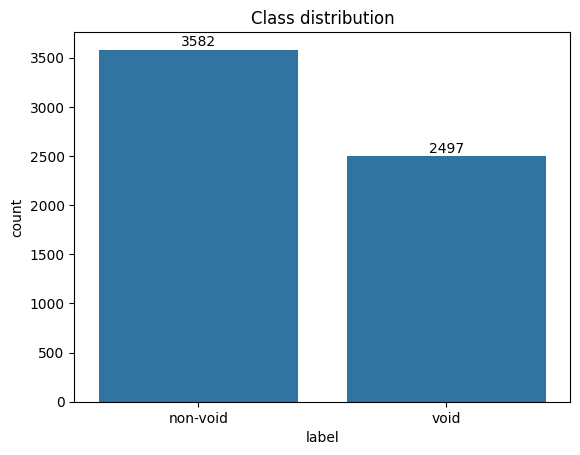

In [1077]:
plt.figure()
ax = sns.countplot(x='label',
                   data=features,
                   order=features.label.value_counts().index)

# Manually add value labels
for i, bar in enumerate(ax.patches):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 10,
            f'{int(height)}',
            ha='center', va='bottom')

plt.title('Class distribution')
plt.show()

In [1078]:
X = features.drop(columns=['label', 'experiment_id'])
y = features['label']
groups = features['experiment_id']

splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(splitter.split(X, y, groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

Scale and fit on training data only

In [1079]:
scaler = StandardScaler()
pca = PCA()

In [1080]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
pca.fit(X_train_scaled)

PCA()

Transform both train and test using the same fitted PCA

In [1081]:
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1


In [1082]:
pca_final = PCA(n_components=3)
X_train_pca = pca_final.fit_transform(X_train_scaled)
X_test_pca = pca_final.transform(X_test_scaled)



In [1083]:
def setup_xgboost_with_imbalance_handling(X_train, y_train, use_smote=False, original_scale_weight=1.27):
    """
    Set up XGBoost with appropriate imbalance handling
    """
    if use_smote:
        print("Applying SMOTE...")
        smote = SMOTE(random_state=42)
        X_balanced, y_balanced = smote.fit_resample(X_train, y_train)
        
        # Check if we still need scale_pos_weight
        unique, counts = np.unique(y_balanced, return_counts=True)
        ratio = counts[0] / counts[1]
        
        if abs(ratio - 1.0) > 0.1:
            scale_weight = ratio
            print(f"Post-SMOTE imbalance detected, using scale_pos_weight: {scale_weight:.3f}")
        else:
            scale_weight = None
            print("Classes balanced after SMOTE, not using scale_pos_weight")
    else:
        print("No SMOTE applied, using original scale_pos_weight")
        X_balanced, y_balanced = X_train, y_train
        scale_weight = original_scale_weight
    
    # Configure XGBoost
    xgb_params = {        
        'n_estimators':200,
        'max_depth':5,
        'learning_rate':0.1,
        'subsample':0.8,
        'colsample_bytree':0.8,
        'random_state':42,
        'eval_metric':'logloss',
        'reg_alpha':0.1,   # L1 regularization
        'reg_lambda':1.0,  # L2 regularization
        'verbosity':0
    }
    
    if scale_weight is not None:
        xgb_params['scale_pos_weight'] = scale_weight
        
        

    
    model = XGBClassifier(**xgb_params)
    
    return model, X_balanced, y_balanced, xgb_params

In [1084]:
model, X_train_final, y_train_final, params = setup_xgboost_with_imbalance_handling(
                                        X_train_pca, 
                                        y_train,
                                        use_smote=False,  # Switch this as needed
                                        original_scale_weight=1.27
                                    )

No SMOTE applied, using original scale_pos_weight


In [1085]:
label_encoder = LabelEncoder()
# Encode y_test and y_train
y_train_encoded = label_encoder.fit_transform(y_train_final) 
y_test_encoded = label_encoder.transform(y_test)

In [1086]:
eval_set = [(X_train_final, y_train_encoded), (X_test_pca, y_test_encoded)]
model.fit(X_train_final, y_train_encoded, eval_set=eval_set, verbose=False)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [1087]:
# Classification report
preds = model.predict(X_test_pca)
y_pred = label_encoder.inverse_transform(preds)
y_pred_prob = model.predict_proba(X_test_pca)
y_pred_labels = label_encoder.inverse_transform(np.argmax(y_pred_prob, axis=1))
report = classification_report(y_test, y_pred)

print(report)

              precision    recall  f1-score   support

    non-void       0.76      0.81      0.78       995
        void       0.67      0.61      0.63       641

    accuracy                           0.73      1636
   macro avg       0.71      0.71      0.71      1636
weighted avg       0.72      0.73      0.72      1636



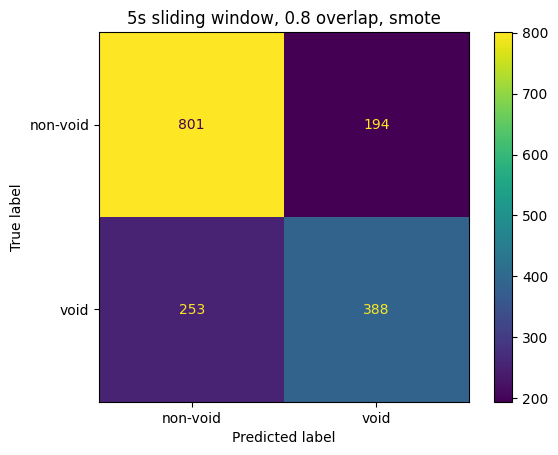

In [1088]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
cm_display = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = ['non-void', 'void'])
cm_display.plot()
plt.title('5s sliding window, 0.8 overlap, smote')
cm_fig_path = 'model_plots/two_class_results/cm_5s_0.8_smote.png'
# plt.savefig(cm_fig_path)
plt.show()


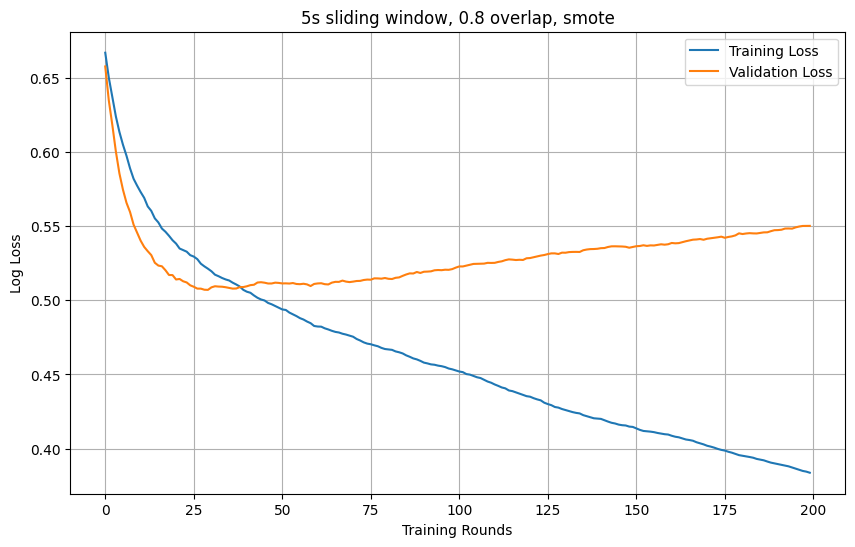

In [1089]:
# Retrieve the evaluation results
results = model.evals_result()
train_loss = results['validation_0']['logloss']
test_loss = results['validation_1']['logloss']

# Plot the loss function
plt.figure(figsize=(10, 6))
plt.plot(train_loss, label='Training Loss')
plt.plot(test_loss, label='Validation Loss')
plt.xlabel('Training Rounds')
plt.ylabel('Log Loss')
plt.title('5s sliding window, 0.8 overlap, smote')
plt.legend()
plt.grid(True)
loss_fig_path = 'model_plots/two_class_results/loss_5s_0.8_smote.png'
# plt.savefig(loss_fig_path)
plt.show()

In [1090]:
report_dict = classification_report(y_test, y_pred, output_dict=True)
report_dict

{'non-void': {'precision': 0.7599620493358634,
  'recall': 0.8050251256281407,
  'f1-score': 0.7818448023426061,
  'support': 995.0},
 'void': {'precision': 0.6666666666666666,
  'recall': 0.6053042121684867,
  'f1-score': 0.634505314799673,
  'support': 641.0},
 'accuracy': 0.7267726161369193,
 'macro avg': {'precision': 0.7133143580012651,
  'recall': 0.7051646688983138,
  'f1-score': 0.7081750585711395,
  'support': 1636.0},
 'weighted avg': {'precision': 0.7234080516030057,
  'recall': 0.7267726161369193,
  'f1-score': 0.7241158221989509,
  'support': 1636.0}}

## Upload to MLFlow

In [1091]:
import mlflow
from mlflow.models.signature import infer_signature

In [ ]:
import mlflow
import mlflow.xgboost
from mlflow.models.signature import infer_signature
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
import os

def log_experiment_run(
    model,
    X_test,
    report_dict,
    loss_fig_path,
    cm_fig_path,
    data_path,
    params,
    experiment_name="Posture Detection - Window Size Tuning - Three Class",
    model_name="XGBoost"
):

    # Set experiment
    mlflow.set_tracking_uri("http://127.0.0.1:5000")
    mlflow.set_experiment(experiment_name)

    run_name = f"{params.get('window_size', 'NA')}s_win_{int(params.get('overlap', 0.0) * 100)}%_overlap"
    # run_name = f"{params.get('window_size', 'NA')}s_win_{int(params.get('overlap', 0.0) * 100)}%_overlap_{params.get('smote')}" # with smote
    
    del params['window_size']
    del params['overlap']

    with mlflow.start_run(run_name=run_name):
        # Log parameters
        mlflow.log_params(params)

        
        mlflow.log_metrics({
            "accuracy": report_dict.get("accuracy", 0.0),
            "recall_non_void": report_dict.get("non-void", {}).get("recall", 0.0),
            "recall_void": report_dict.get("void", {}).get("recall", 0.0),
            "f1_score_macro": report_dict.get("macro avg", {}).get("f1-score", 0.0)
        })

        # Log model with signature
        # input_example = X_test.iloc[:1]
        input_example = X_test[:1]
        signature = infer_signature(X_test, model.predict(X_test))

        try:
            mlflow.xgboost.log_model(
                xgb_model=model,
                artifact_path=model_name,
                input_example=input_example,
                signature=signature
            )
        except Exception as e:
            print("Error logging model:", e)
        
        # try:
        #     mlflow.log_artifact(cm_fig_path)
        # except Exception as e:
        #     print("Error logging artifact:", e)
            
        # try:
        #     mlflow.log_artifact(loss_fig_path)
        # except Exception as e:
        #     print("Error logging artifact:", e)
        
        # try:    
        #     mlflow.log_artifact(data_path)
        # except Exception as e:
        #     print("Error logging artifact:", e)


In [ ]:
from sklearn.metrics import classification_report

# Example parameters
params['window_size'] = 5
params['overlap'] = 0.8
params['smote'] = 'smote'
params['exp_name'] = '5s_0.8_overlap'


# y_pred = model.predict(X_test)
report_dict = classification_report(y_test, y_pred, output_dict=True)

log_experiment_run(model, X_test_pca, report_dict, cm_fig_path, data_path, loss_fig_path, params)